# GEO Data Preprocessing: GSE73754 - Ankylosing Spondylitis


In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Step 1: Loading GEO SMT file

In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from config import RAW_DIR
file_path = RAW_DIR / "GSE73754_series_matrix.txt"
with open(file_path, 'r') as f:
    lines = f.readlines()
print(f"Total lines in file: {len(lines)}")
for line in lines[:8]:
    print(line.strip())

Total lines in file: 47389
!Series_title	"Sexual Dimorphism in the Th17 Signature of Ankylosing Spondylitis"
!Series_geo_accession	"GSE73754"
!Series_status	"Public on Oct 07 2015"
!Series_submission_date	"Oct 06 2015"
!Series_last_update_date	"Sep 08 2020"
!Series_pubmed_id	"26473967"
!Series_summary	"Male AS patients have an elevated Th17 cell frequency vs. female AS patients (Gracey et al, Arthritis and Rheumatology, 2015). This analysis was performed to further examine differences between male and female AS patients"
!Series_overall_design	"AS patients were compared to healthy controls (HC). For sex-specific anaylsis, three groups were compared: F-HC vs. M-HC, M-AS vs. M-HC and F-AS vs. F-HC. A one way ANOVA was performed to identify genes differentially regulated in male and female AS patients"


## Step 2: Extracting Sample Metadata

In [10]:
IDs = []
Titles = []
Status = []

for line in lines:
    if line.startswith('!Sample_geo_accession'):
        IDs = line.strip().split('\t')[1:]
    if line.startswith('!Sample_title'):
        Titles = line.strip().split('\t')[1:]
    if line.startswith('!Sample_characteristics_ch1'):
        if 'disease' in line.lower():
            chars = line.strip().split('\t')[1:]
            Status = [1 if 'ankylosing' in c.lower() else 0 for c in chars]

sample_info = pd.DataFrame({
    'Sample_id': IDs,
    'Title': Titles,
    'Disease_status': Status
})
print("Sample Details:")
print(sample_info.head())
print(f"\nTotal samples: {len(sample_info)}")
print(f"AS patients: {sum(sample_info['Disease_status'] == 1)}")
print(f"Healthy controls: {sum(sample_info['Disease_status'] == 0)}")

Sample Details:
      Sample_id                Title  Disease_status
0  "GSM1902130"  "AS [9963831033_D]"               1
1  "GSM1902131"  "AS [9965280034_B]"               1
2  "GSM1902132"  "AS [9963831032_I]"               1
3  "GSM1902133"  "AS [9963831051_A]"               1
4  "GSM1902134"  "AS [9963831032_L]"               1

Total samples: 72
AS patients: 52
Healthy controls: 20


## Step 3: Extract Expression Matrix

In [ ]:

data_start = 0
data_end = 0
for idx, line in enumerate(lines):
    if line.startswith('!series_matrix_table_begin'):
        data_start = idx + 1
    if line.startswith('!series_matrix_table_end'):
        data_end = idx
        break
print(f"Data starts at line: {data_start}")
print(f"Data ends at line: {data_end}")

# Extract data section
data_lines = lines[data_start:data_end]

# Parse header
header = data_lines[0].strip().replace('"', '').split('\t')

# Parse data rows
data_rows = []
for line in data_lines[1:]:
    row = line.strip().split('\t')
    data_rows.append(row)

# Create dataframe
expression_df = pd.DataFrame(data_rows, columns=header)
expression_df.set_index('ID_REF', inplace=True)

# Convert to numeric
expression_df = expression_df.apply(pd.to_numeric, errors='coerce')

print(f"\nExpression matrix shape: {expression_df.shape}")
print(f"Genes/Probes: {expression_df.shape[0]}")
print(f"Samples: {expression_df.shape[1]}")

expression_df.head()

Data starts at line: 64
Data ends at line: 47388

Expression matrix shape: (47323, 72)
Genes/Probes: 47323
Samples: 72


,GSM1902130,GSM1902131,GSM1902132,GSM1902133,GSM1902134,GSM1902135,GSM1902136,GSM1902137,GSM1902138,GSM1902139,...,GSM1902192,GSM1902193,GSM1902194,GSM1902195,GSM1902196,GSM1902197,GSM1902198,GSM1902199,GSM1902200,GSM1902201
ID_REF,,,,,,,,,,,,,,,,,,,,,
"""ILMN_1343291""",14.723105,14.974196,14.875049,14.262832,14.380508,14.737535,14.994368,14.517866,14.751615,14.937985,...,14.546172,14.609772,14.502806,14.751615,15.046889,14.751615,14.890210,14.859273,14.937985,14.455832
"""ILMN_1343295""",10.796875,10.545005,10.617579,10.663274,10.373557,11.070106,10.609179,10.614307,10.612894,10.263954,...,10.551885,10.677234,10.606567,10.688255,10.647923,10.527452,10.519320,10.395747,10.680664,10.368892
"""ILMN_1651199""",6.625879,6.658650,6.614950,6.729367,6.670856,6.751337,6.658062,6.658457,6.644127,6.698253,...,6.663772,6.603572,6.649300,6.763689,6.677779,6.550622,6.693903,6.742800,6.584209,6.593124
"""ILMN_1651209""",6.762562,6.775621,6.630290,6.822824,6.670856,6.713077,6.704106,6.854264,6.767462,6.659816,...,6.835929,6.729711,6.770642,6.811416,6.824817,6.736938,6.766212,6.765388,6.690326,6.719627
"""ILMN_1651210""",6.800612,6.596698,6.613691,6.504107,6.708310,6.593606,6.674507,6.741474,6.683399,6.752126,...,6.612110,6.662521,6.708362,6.758281,6.690449,6.609686,6.743372,6.715278,6.601116,6.584874


## Step 4: Quality Control

BEFORE QC:
Genes: 47323
Missing values: 0

After removing high-missing genes: 47323 genes
Missing values after imputation: 0
After removing low-variance genes: 35492 genes


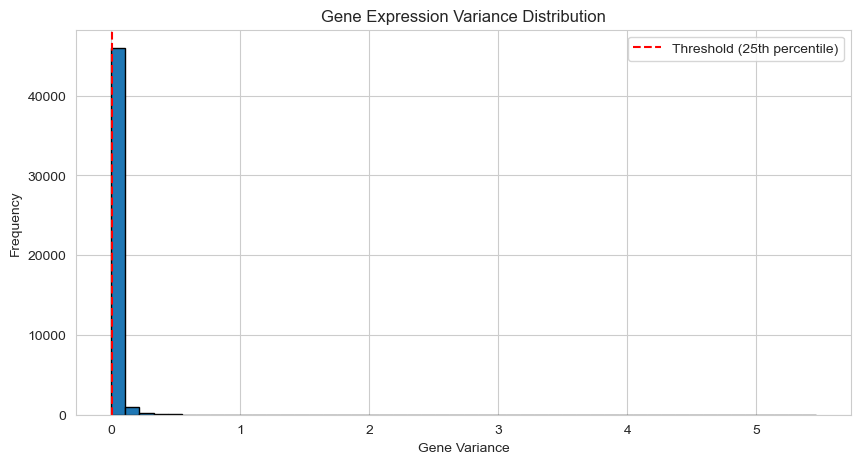

In [6]:
print("BEFORE QC:")
print(f"Genes: {expression_df.shape[0]}")
print(f"Missing values: {expression_df.isnull().sum().sum()}")

# 1. Remove genes with >20% missing values
missing_pct = expression_df.isnull().sum(axis=1) / expression_df.shape[1]
genes_to_keep = missing_pct < 0.2
expression_df = expression_df[genes_to_keep]
print(f"\nAfter removing high-missing genes: {expression_df.shape[0]} genes")

# 2. Impute remaining missing values with median
expression_df = expression_df.fillna(expression_df.median(axis=1), axis=0)
print(f"Missing values after imputation: {expression_df.isnull().sum().sum()}")

# 3. Remove low-variance genes (bottom 25%)
gene_variance = expression_df.var(axis=1)
var_threshold = gene_variance.quantile(0.25)
expression_df = expression_df[gene_variance > var_threshold]
print(f"After removing low-variance genes: {expression_df.shape[0]} genes")

# Visualize variance distribution
plt.figure(figsize=(10, 5))
plt.hist(gene_variance, bins=50, edgecolor='black')
plt.axvline(var_threshold, color='red', linestyle='--', label=f'Threshold (25th percentile)')
plt.xlabel('Gene Variance')
plt.ylabel('Frequency')
plt.title('Gene Expression Variance Distribution')
plt.legend()
plt.show()

## Step 5: Normalization

Normalization Statistics:
Mean: -0.000
Std: 0.985
Min: -5.290
Max: 8.272


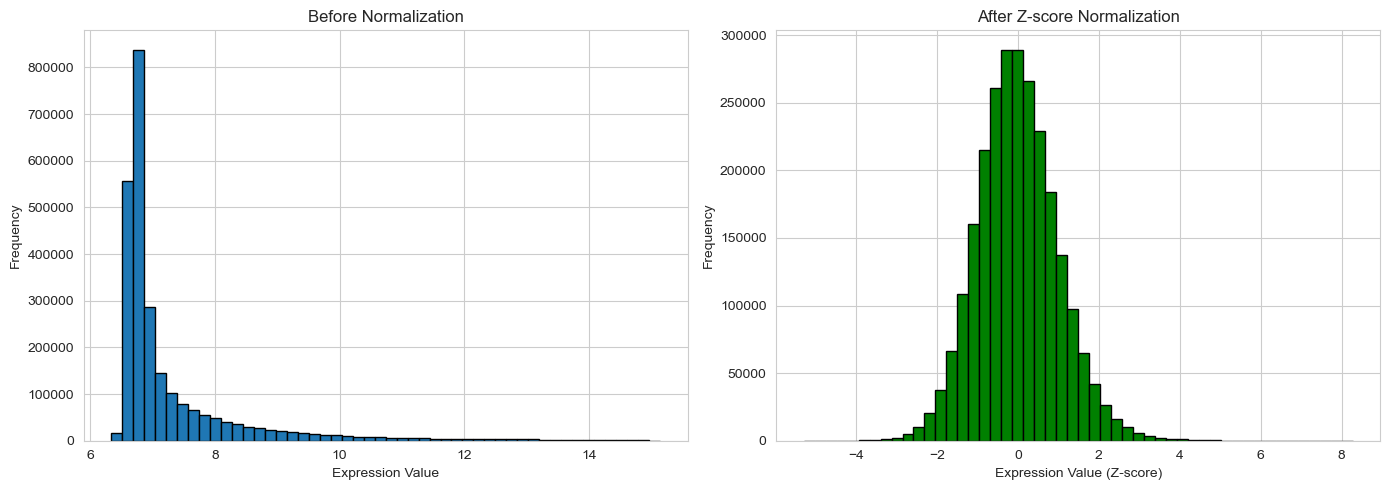

In [7]:
# Z-score normalization per gene
expression_normalized = expression_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

print("Normalization Statistics:")
print(f"Mean: {expression_normalized.mean().mean():.3f}")
print(f"Std: {expression_normalized.std().mean():.3f}")
print(f"Min: {expression_normalized.min().min():.3f}")
print(f"Max: {expression_normalized.max().max():.3f}")

# Before/After comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before normalization
axes[0].hist(expression_df.values.flatten(), bins=50, edgecolor='black')
axes[0].set_title('Before Normalization')
axes[0].set_xlabel('Expression Value')
axes[0].set_ylabel('Frequency')

# After normalization
axes[1].hist(expression_normalized.values.flatten(), bins=50, edgecolor='black', color='green')
axes[1].set_title('After Z-score Normalization')
axes[1].set_xlabel('Expression Value (Z-score)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Step 6: Create ML-Ready Dataset

In [8]:
# Transpose: samples as rows, genes as columns
ml_data = expression_normalized.T

# Add disease status label
ml_data['disease_status'] = sample_info['disease_status'].values

# Set sample IDs as index
ml_data.index = sample_info['sample_id'].values

print("Final ML Dataset:")
print(f"Shape: {ml_data.shape}")
print(f"Samples: {ml_data.shape[0]}")
print(f"Genes (features): {ml_data.shape[1] - 1}")
print(f"\nClass distribution:")
print(ml_data['disease_status'].value_counts())

ml_data.head()

Final ML Dataset:
Shape: (72, 35493)
Samples: 72
Genes (features): 35492

Class distribution:
disease_status
1    52
0    20
Name: count, dtype: int64


ID_REF,"""ILMN_1343291""","""ILMN_1343295""","""ILMN_1651209""","""ILMN_1651210""","""ILMN_1651221""","""ILMN_1651228""","""ILMN_1651229""","""ILMN_1651237""","""ILMN_1651249""","""ILMN_1651253""",...,"""ILMN_3311125""","""ILMN_3311135""","""ILMN_3311145""","""ILMN_3311150""","""ILMN_3311155""","""ILMN_3311165""","""ILMN_3311180""","""ILMN_3311185""","""ILMN_3311190""",disease_status
"""GSM1902130""",0.222525,0.946625,0.479527,1.299650,-0.250728,0.511102,1.024195,0.381454,1.699836,0.431121,...,1.559897,-1.806520,0.866146,0.110604,-0.500089,0.630175,1.303932,-0.576526,-1.781692,1
"""GSM1902131""",1.363394,-0.302656,0.633821,-0.896111,2.562736,0.602007,1.550458,-0.972826,-0.376729,-2.122367,...,-1.284362,2.109531,-0.997402,0.036757,-0.531441,-1.088084,1.016161,-0.246699,-0.123491,1
"""GSM1902132""",0.912906,0.057313,-1.083277,-0.713129,0.466518,-0.230218,-0.818869,-0.047100,-1.162916,-0.422749,...,0.134123,-0.394616,-0.277853,-0.266428,0.877264,-0.088569,-1.157596,0.674134,-2.008517,1
"""GSM1902133""",-1.868797,0.283961,1.191520,-1.893138,-1.289428,-1.653800,1.365852,-0.132555,0.424163,0.152613,...,0.087079,-1.603560,-0.935819,0.209938,0.196994,1.657298,-0.618197,0.871633,0.250792,1
"""GSM1902134""",-1.334118,-1.153043,-0.603990,0.305732,-0.605825,-0.716238,-0.438635,0.936307,0.192992,-0.551342,...,1.451521,-1.204039,-0.573846,1.600897,-3.262030,-1.179715,-0.345253,-1.823003,0.967801,1


## Step 7: Quick Exploratory Analysis

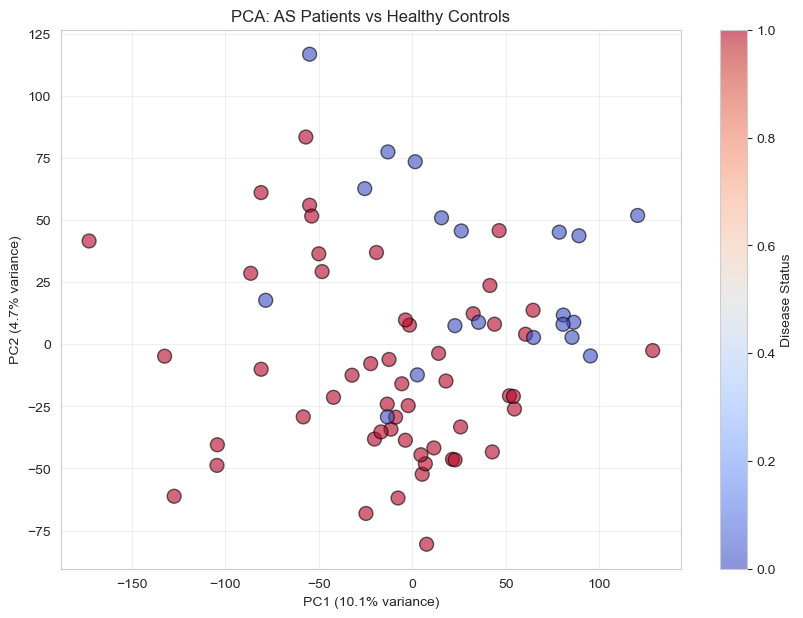

Total variance explained by PC1+PC2: 14.8%


In [9]:
# PCA visualization
from sklearn.decomposition import PCA

X = ml_data.drop('disease_status', axis=1)
y = ml_data['disease_status']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', 
                     s=100, alpha=0.6, edgecolors='black')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: AS Patients vs Healthy Controls')
plt.colorbar(scatter, label='Disease Status')
plt.grid(alpha=0.3)
plt.show()

print(f"Total variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_):.1%}")

## Step 8: Save Processed Data

In [ ]:
import os

# Output path
output_file = "Desktop/AutoimmuneBiomarkers/data/processed/as_ml_ready.csv"

# Create directory if needed
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Save
ml_data.to_csv(output_file)

print(f"✅ Saved processed data to: {output_file}")
print(f"\nFile size: {os.path.getsize(output_file) / 1024:.1f} KB")
print(f"\nTo load this data in future scripts:")
print(f"  data = pd.read_csv('{output_file}', index_col=0)")
print(f"  X = data.drop('disease_status', axis=1)")
print(f"  y = data['disease_status']")